In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu

In [2]:
df = pd.read_csv("//Users/zofiabrodewicz/Documents/GitHub/Bachelor/collaborations_with_distances.csv")
df["log_avg_streams"] = np.log10(df["avg_streams"])

## Exploratory analysis of the distances 


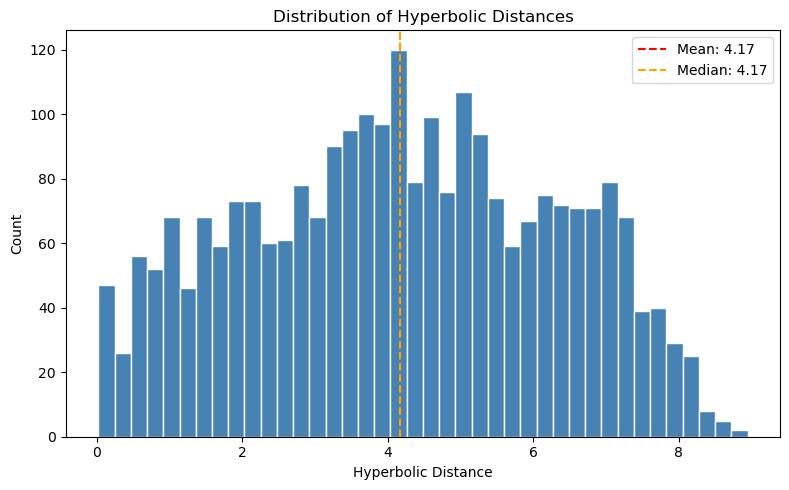

In [3]:
#  Plot 1: Distribution of distances 
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["hyperbolic_distance"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(df["hyperbolic_distance"].mean(), color="red", linestyle="--",
           label=f'Mean: {df["hyperbolic_distance"].mean():.2f}')
ax.axvline(df["hyperbolic_distance"].median(), color="orange", linestyle="--",
           label=f'Median: {df["hyperbolic_distance"].median():.2f}')
ax.set_title("Distribution of Hyperbolic Distances")
ax.set_xlabel("Hyperbolic Distance")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()



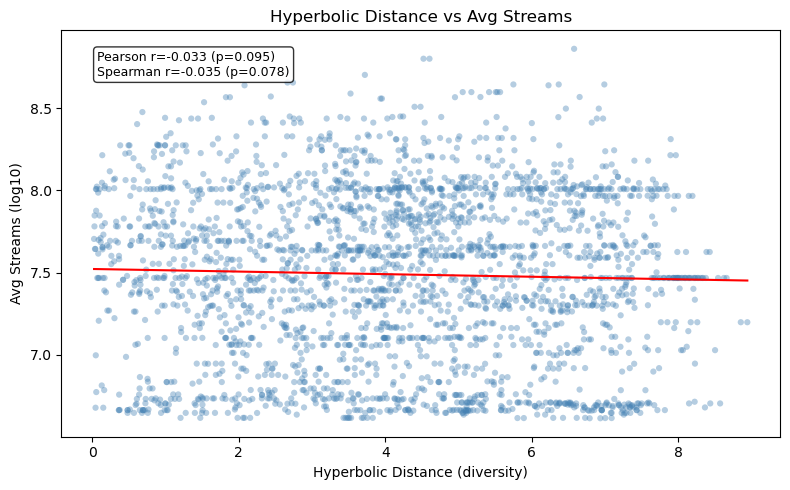

In [4]:
# Plot 2: Distance vs avg_streams 
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["hyperbolic_distance"], df["log_avg_streams"],
           alpha=0.4, color="steelblue", edgecolors="none", s=20)
z = np.polyfit(df["hyperbolic_distance"], df["log_avg_streams"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["hyperbolic_distance"].min(), df["hyperbolic_distance"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=1.5)
pearson_r, pearson_p = stats.pearsonr(df["hyperbolic_distance"], df["log_avg_streams"])
spearman_r, spearman_p = stats.spearmanr(df["hyperbolic_distance"], df["log_avg_streams"])
ax.set_title("Hyperbolic Distance vs Avg Streams")
ax.set_xlabel("Hyperbolic Distance (diversity)")
ax.set_ylabel("Avg Streams (log10)")
ax.text(0.05, 0.95,
        f"Pearson r={pearson_r:.3f} (p={pearson_p:.3f})\nSpearman r={spearman_r:.3f} (p={spearman_p:.3f})",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()


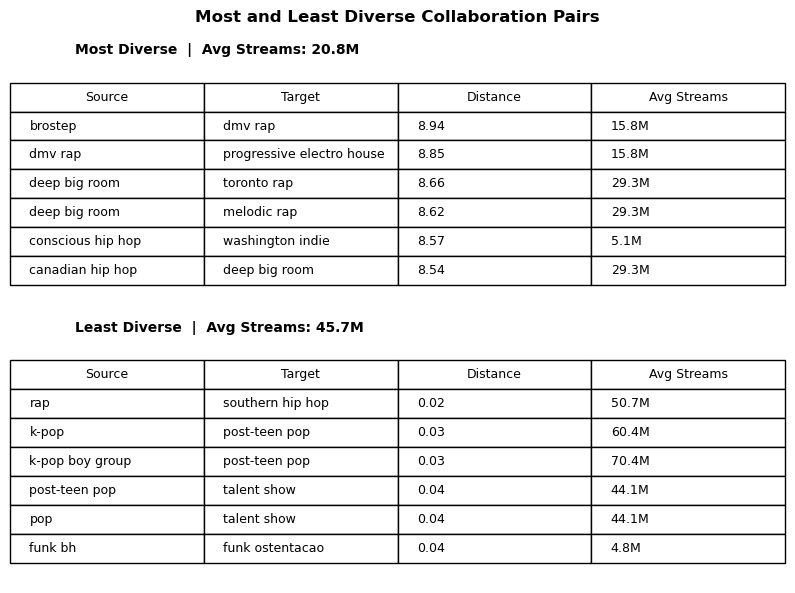

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
fig.suptitle("Most and Least Diverse Collaboration Pairs",
             fontsize=12, fontweight="bold")

top_diverse = df.nlargest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]
top_similar = df.nsmallest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]

# average streams per group
avg_streams_diverse = top_diverse["avg_streams"].mean()
avg_streams_similar = top_similar["avg_streams"].mean()

diverse_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_diverse.iterrows()]
similar_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_similar.iterrows()]

for ax, data, title, avg_streams in zip(
    axes,
    [diverse_data, similar_data],
    ["Most Diverse", "Least Diverse"],
    [avg_streams_diverse, avg_streams_similar]
):
    ax.axis("off")
    ax.set_title(f"{title}  |  Avg Streams: {avg_streams/1e6:.1f}M",
                 fontsize=10, fontweight="bold", loc="left")
    table = ax.table(cellText=data,
                     colLabels=["Source", "Target", "Distance", "Avg Streams"],
                     loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()

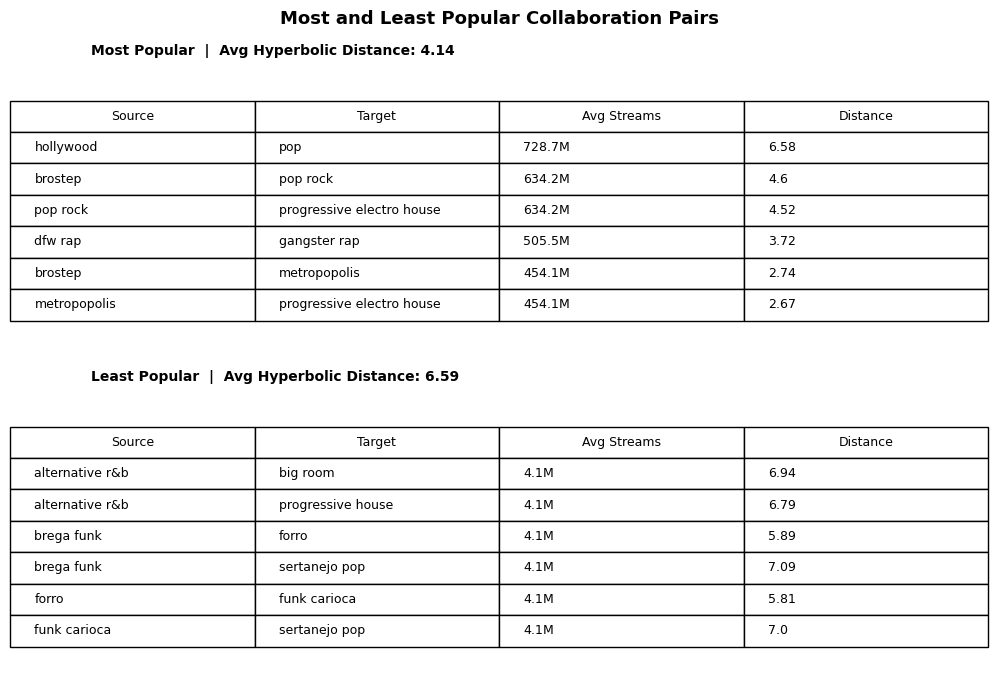

In [6]:
top_popular = df.nlargest(6, "avg_streams")[["source", "target", "avg_streams", "hyperbolic_distance"]].copy()
least_popular = df.nsmallest(6, "avg_streams")[["source", "target", "avg_streams", "hyperbolic_distance"]].copy()

def format_streams(val):
    return f"{val/1e6:.1f}M"

top_popular["avg_streams"] = top_popular["avg_streams"].apply(format_streams)
least_popular["avg_streams"] = least_popular["avg_streams"].apply(format_streams)
top_popular["hyperbolic_distance"] = top_popular["hyperbolic_distance"].round(2)
least_popular["hyperbolic_distance"] = least_popular["hyperbolic_distance"].round(2)

avg_dist_popular = df.nlargest(6, "avg_streams")["hyperbolic_distance"].mean()
avg_dist_least = df.nsmallest(6, "avg_streams")["hyperbolic_distance"].mean()


fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle("Most and Least Popular Collaboration Pairs", 
             fontsize=13, fontweight="bold")

for ax, data, title, avg_dist in zip(
    axes,
    [top_popular, least_popular],
    ["Most Popular", "Least Popular"],
    [avg_dist_popular, avg_dist_least]
):
    ax.axis("off")
    ax.set_title(f"{title}  |  Avg Hyperbolic Distance: {avg_dist:.2f}",
                 fontsize=10, fontweight="bold", loc="left", pad=8)
    
    table = ax.table(
        cellText=data.values,
        colLabels=["Source", "Target", "Avg Streams", "Distance"],
        loc="center",
        cellLoc="left"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.6)

plt.tight_layout()
plt.show()

## Looking at average streams and average diversity 

In [ ]:
# load the data
df_2017 = pd.read_csv("collaborations_with_distances2017.csv")
df_2018 = pd.read_csv("collaborations_with_distances2018.csv")
df_2019 = pd.read_csv("collaborations_with_distances2019.csv")

df_2017["year"] = 2017
df_2018["year"] = 2018
df_2019["year"] = 2019

all_years = pd.concat([df_2017, df_2018, df_2019], ignore_index=True)

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/2811424504.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/2811424504.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/2811424504.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain c

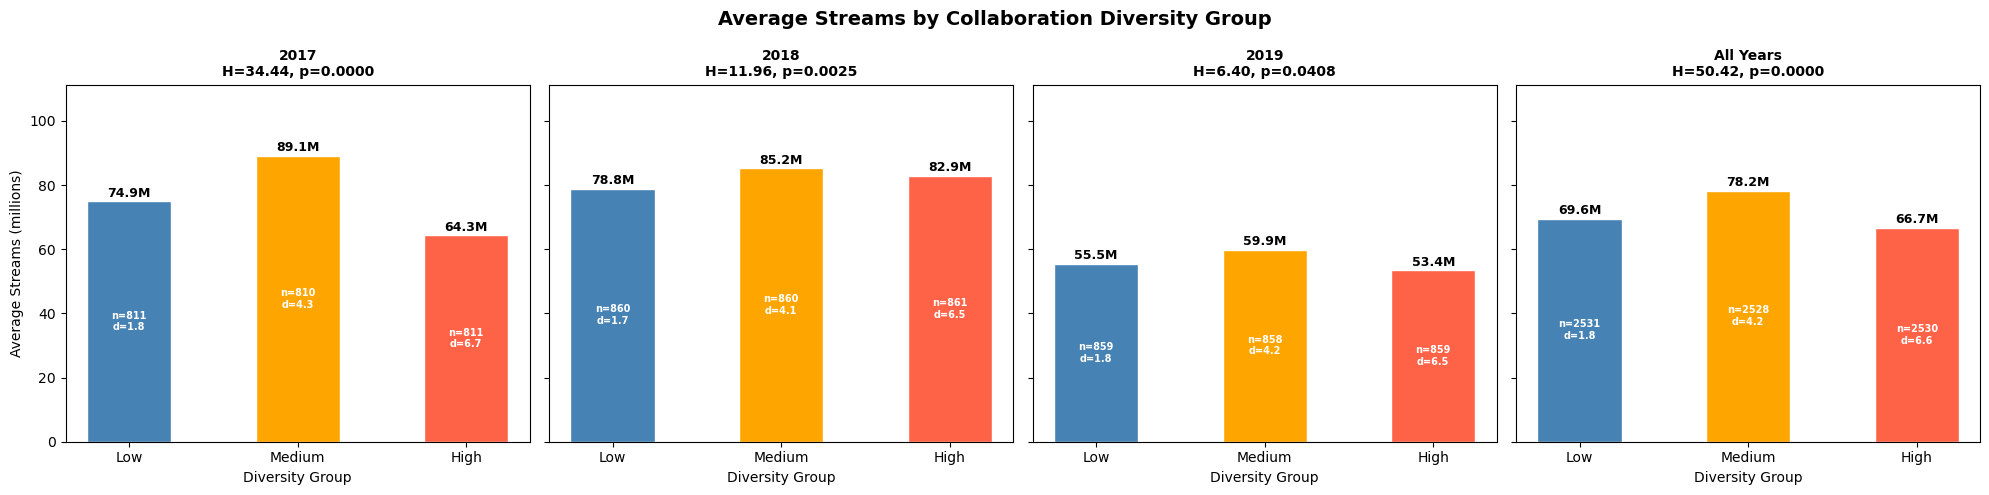

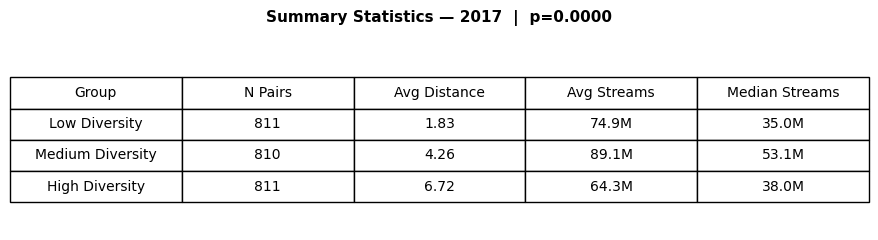

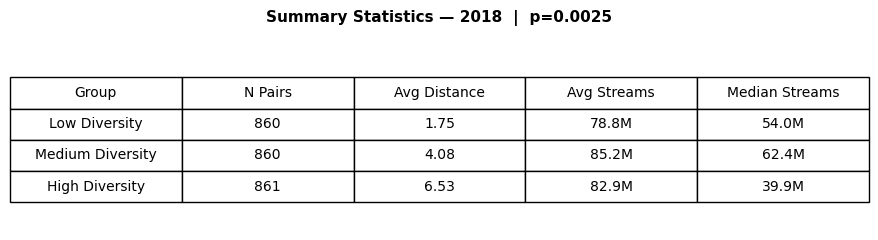

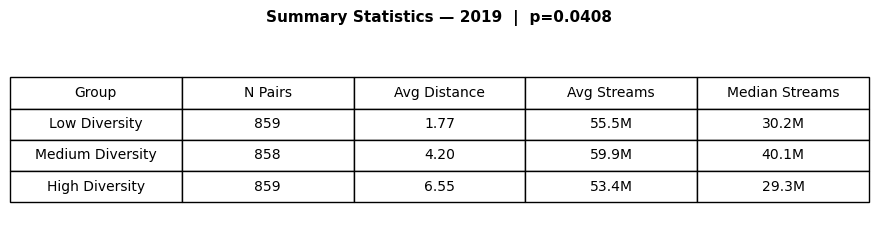

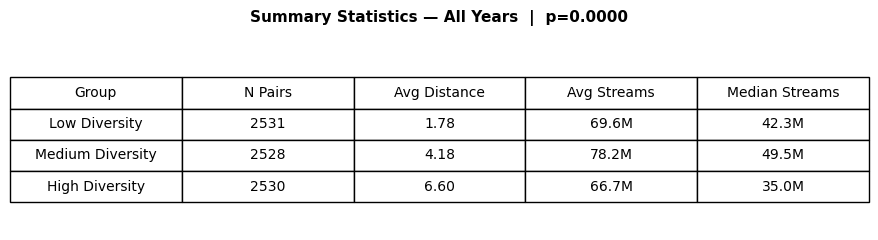

In [14]:
# ── compute stats for all datasets first ─────────────────────────────────────
results = {}
for label, df in datasets.items():
    df = df.copy()
    df["diversity_group"] = pd.qcut(
        df["hyperbolic_distance"],
        q=3,
        labels=["Low Diversity", "Medium Diversity", "High Diversity"]
    )
    group_stats = df.groupby("diversity_group").agg(
        n_pairs=("hyperbolic_distance", "count"),
        avg_distance=("hyperbolic_distance", "mean"),
        avg_streams=("avg_streams", "mean"),
        median_streams=("avg_streams", "median")
    ).reset_index()
    groups = [g["avg_streams"].values for _, g in df.groupby("diversity_group")]
    stat, p = stats.kruskal(*groups)
    results[label] = {"group_stats": group_stats, "stat": stat, "p": p}

# ── one figure with 4 bar charts side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle("Average Streams by Collaboration Diversity Group",
             fontsize=14, fontweight="bold")

colors = ["steelblue", "orange", "tomato"]

for ax, (label, res) in zip(axes, results.items()):
    group_stats = res["group_stats"]
    p = res["p"]
    stat = res["stat"]

    bars = ax.bar(["Low", "Medium", "High"],
                  group_stats["avg_streams"] / 1e6,
                  color=colors, edgecolor="white", width=0.5)

    for bar, val in zip(bars, group_stats["avg_streams"] / 1e6):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}M",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    for bar, n, avg_d in zip(bars, group_stats["n_pairs"], group_stats["avg_distance"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"n={n}\nd={avg_d:.1f}",
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold")


    ax.set_title(f"{label}\nH={stat:.2f}, p={p:.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Diversity Group")
    if label == "2017":
        ax.set_ylabel("Average Streams (millions)")
    ax.set_ylim(0, max(r["group_stats"]["avg_streams"].max() for r in results.values()) / 1e6 * 1.25)

plt.tight_layout()
plt.show()

# ── summary tables printed after ──────────────────────────────────────────────
for label, res in results.items():
    group_stats = res["group_stats"]
    p = res["p"]

    fig, ax = plt.subplots(figsize=(9, 2.5))
    ax.axis("off")
    table_data = [
        [row["diversity_group"],
         f'{row["n_pairs"]}',
         f'{row["avg_distance"]:.2f}',
         f'{row["avg_streams"]/1e6:.1f}M',
         f'{row["median_streams"]/1e6:.1f}M']
        for _, row in group_stats.iterrows()
    ]
    table = ax.table(
        cellText=table_data,
        colLabels=["Group", "N Pairs", "Avg Distance", "Avg Streams", "Median Streams"],
        loc="center", cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.3, 2.0)
    ax.set_title(f"Summary Statistics — {label}  |  p={p:.4f}",
                 fontsize=11, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()

 The medium diversity group has the smallest gap between average and median, meaning it has the most consistent performance. Low and high diversity groups have larger gaps, meaning their averages are pulled up by a few outlier mega-hits while most collaborations in those groups perform more modestly.

── Kruskal-Wallis per family ────────────────────────────
Latin: H=10.40, p=0.0055
Hip Hop: H=1.22, p=0.5434
Rock: H=14.50, p=0.0007
Electronic: H=16.44, p=0.0003
Pop: H=8.37, p=0.0152


/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = family_df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fal

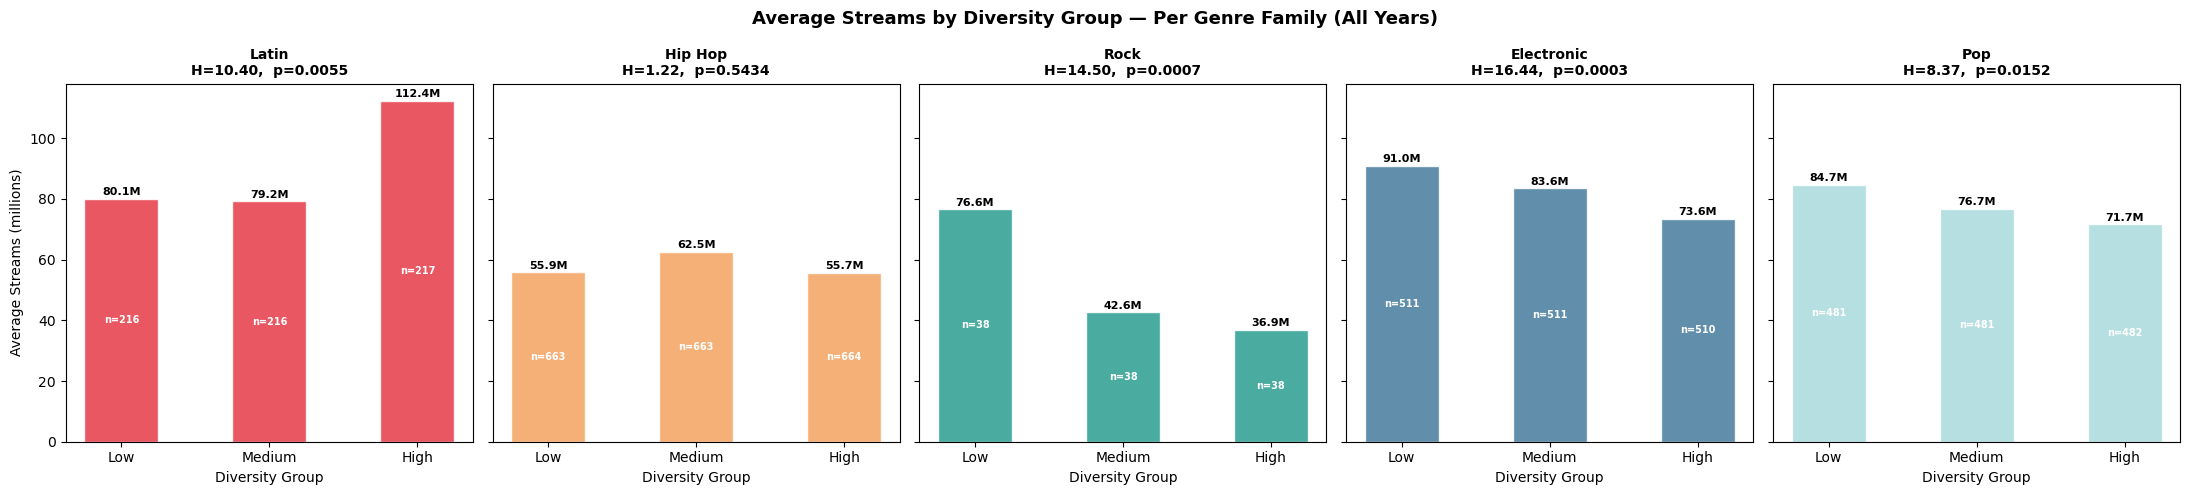

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = family_df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

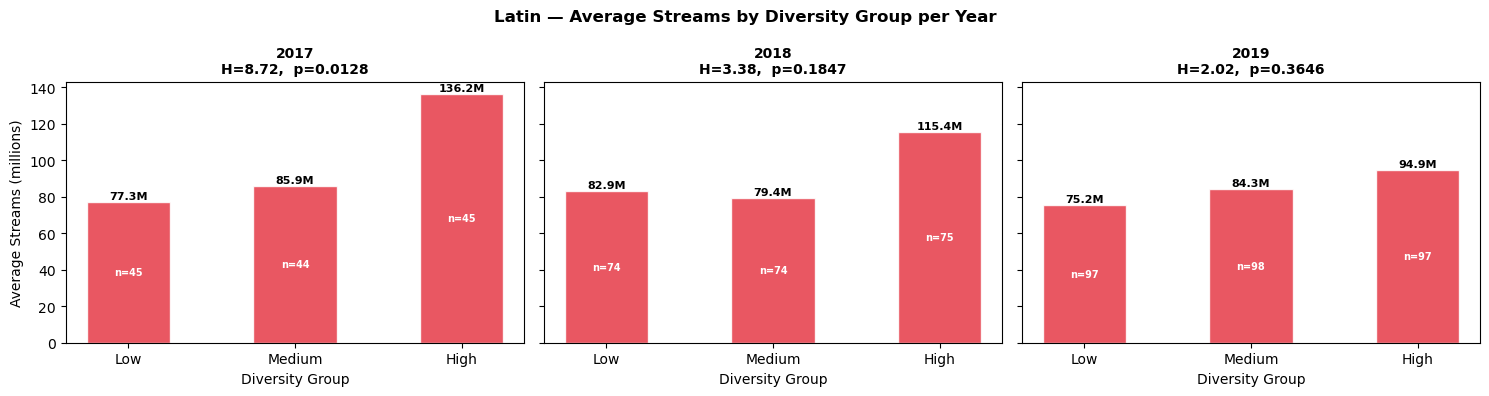

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = family_df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

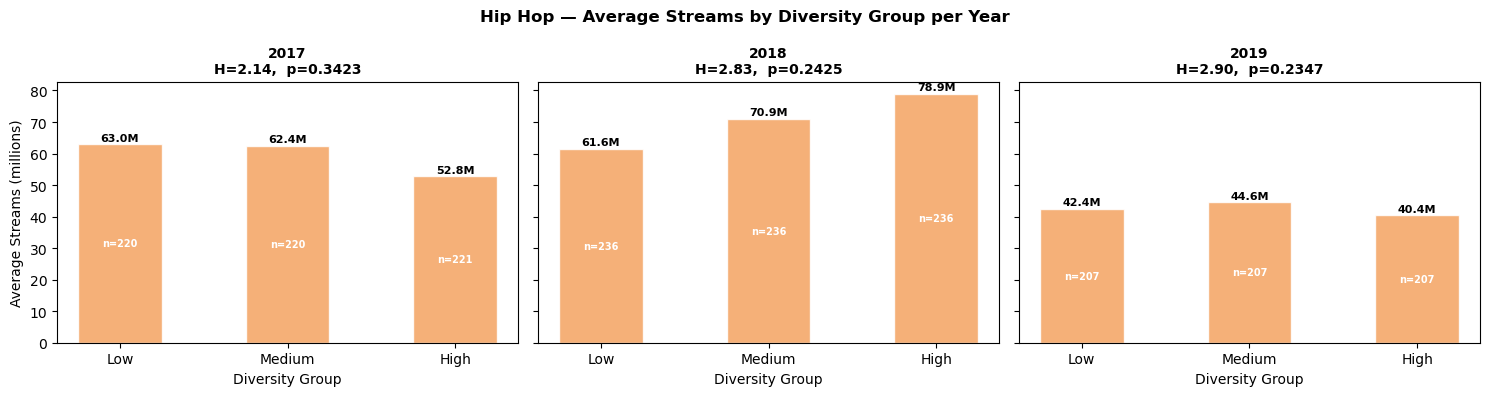

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = family_df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

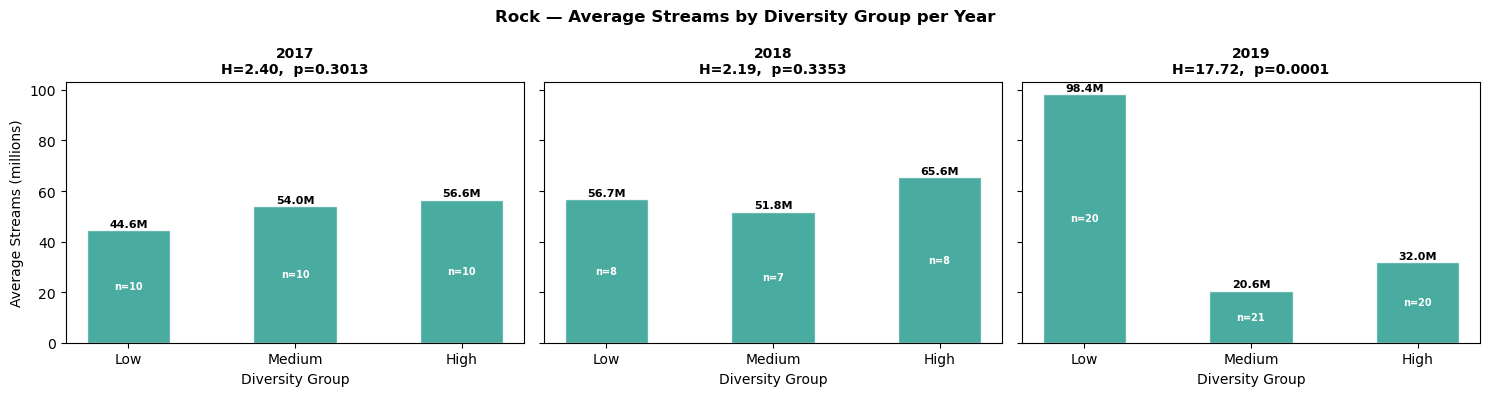

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = family_df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

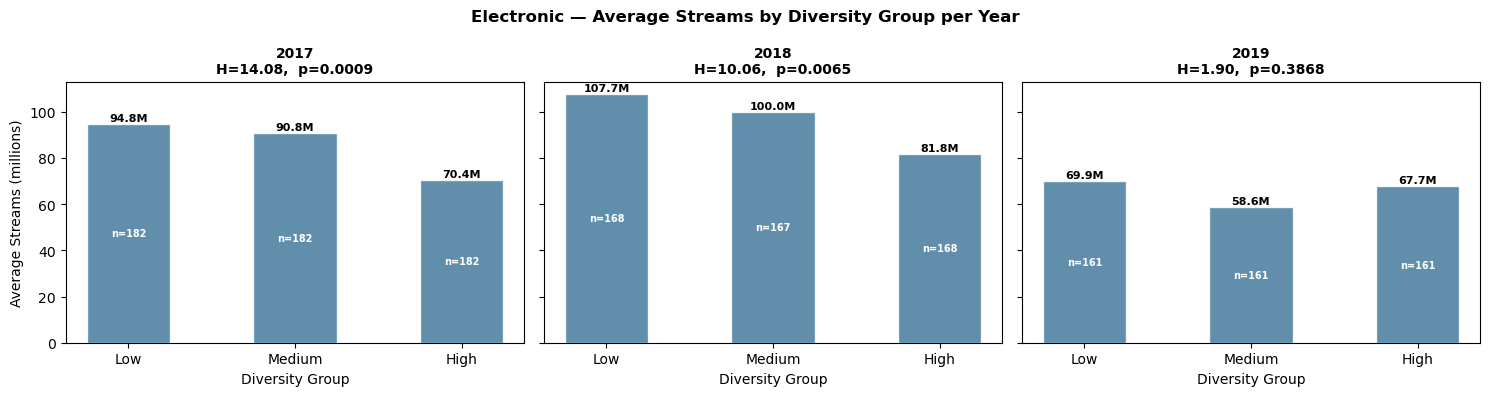

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = family_df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_34006/3765463594.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

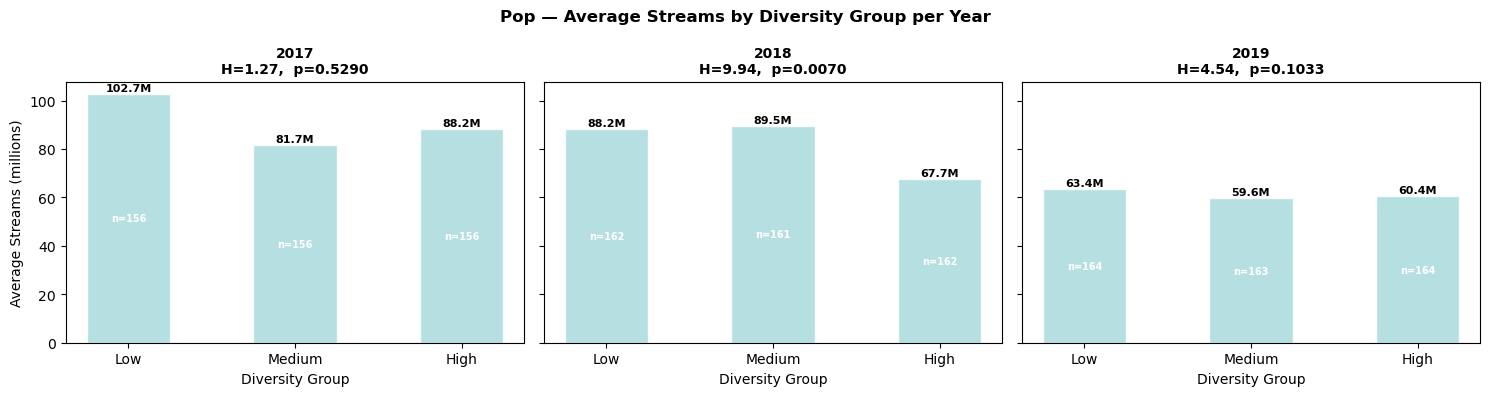

In [ ]:
# ── genre families ────────────────────────────────────────────────────────────

FAMILIES = {
    'Pop': {
        'genres': ['pop', 'dance pop', 'canadian pop', 'uk pop', 'art pop',
                   'post-teen pop', 'bedroom pop', 'indie pop', 'viral pop',
                   'new wave pop', 'singer-songwriter pop', 'pov: indie'],
        'color': '#e63946'
    },
    'Rap': {
        'genres': ['rap', 'pop rap', 'melodic rap', 'cloud rap', 'gangster rap',
                   'east coast hip hop', 'southern hip hop', 'atl hip hop',
                   'french hip hop', 'west coast rap', 'conscious hip hop',
                   'chicago rap'],
        'color': '#f4a261'
    },
    'Rock': {
        'genres': ['rock', 'modern rock', 'classic rock', 'alternative rock',
                   'hard rock', 'post-grunge', 'album rock', 'soft rock',
                   'indie rock', 'folk rock', 'pop rock', 'alternative metal'],
        'color': '#2a9d8f'
    },
    'Urbano Latino': {
        'genres': ['urbano latino', 'trap latino', 'reggaeton', 'musica mexicana',
                   'corrido', 'norteno', 'sierreno', 'banda', 'sad sierreno',
                   'reggaeton colombiano', 'latin pop', 'latin alternative'],
        'color': '#8338ec'
    },
    'Hip Hop': {
        'genres': ['hip hop', 'trap', 'atl hip hop', 'southern hip hop',
                   'urban contemporary', 'east coast hip hop', 'conscious hip hop',
                   'french hip hop', 'german hip hop', 'canadian hip hop',
                   'latin hip hop', 'old school hip hop'],
        'color': '#457b9d'
    },
}


# ── assign family to each row ─────────────────────────────────────────────────
# a row belongs to a family if source OR target is in that family
def assign_family(df, family_name, family_genres):
    mask = df["source"].isin(family_genres) | df["target"].isin(family_genres)
    family_df = df[mask].copy()
    family_df["family"] = family_name
    return family_df

# ── compute stats and plot per family ────────────────────────────────────────
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(22, 5), sharey=True)
fig.suptitle("Average Streams by Diversity Group — Per Genre Family (All Years)",
             fontsize=13, fontweight="bold")

print("── Kruskal-Wallis per family ────────────────────────────")

for ax, (family_name, family_info) in zip(axes, FAMILIES.items()):
    family_df = assign_family(all_years, family_name, family_info["genres"])

    if len(family_df) < 30:
        print(f"{family_name}: not enough data ({len(family_df)} pairs)")
        ax.set_title(f"{family_name}\nnot enough data")
        ax.axis("off")
        continue

    family_df["diversity_group"] = pd.qcut(
        family_df["hyperbolic_distance"],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    group_stats = family_df.groupby("diversity_group").agg(
        n_pairs=("hyperbolic_distance", "count"),
        avg_distance=("hyperbolic_distance", "mean"),
        avg_streams=("avg_streams", "mean"),
    ).reset_index()

    groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
    stat, p = stats.kruskal(*groups)
    print(f"{family_name}: H={stat:.2f}, p={p:.4f}")

    color = family_info["color"]
    bars = ax.bar(group_stats["diversity_group"],
                  group_stats["avg_streams"] / 1e6,
                  color=color, edgecolor="white", width=0.5, alpha=0.85)

    for bar, val in zip(bars, group_stats["avg_streams"] / 1e6):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}M",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    for bar, n in zip(bars, group_stats["n_pairs"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"n={n}",
                ha="center", va="center", fontsize=7,
                color="white", fontweight="bold")

    ax.set_title(f"{family_name}\nH={stat:.2f},  p={p:.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Diversity Group")
    if family_name == "Latin":
        ax.set_ylabel("Average Streams (millions)")

plt.tight_layout()
plt.show()

# ── per family per year ───────────────────────────────────────────────────────
datasets = {"2017": df_2017, "2018": df_2018, "2019": df_2019}

for family_name, family_info in FAMILIES.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"{family_name} — Average Streams by Diversity Group per Year",
                 fontsize=12, fontweight="bold")

    for ax, (year_label, year_df) in zip(axes, datasets.items()):
        family_df = assign_family(year_df, family_name, family_info["genres"])

        if len(family_df) < 10:
            ax.set_title(f"{year_label}\nnot enough data")
            ax.axis("off")
            continue

        family_df["diversity_group"] = pd.qcut(
            family_df["hyperbolic_distance"],
            q=3,
            labels=["Low", "Medium", "High"]
        )

        group_stats = family_df.groupby("diversity_group").agg(
            n_pairs=("hyperbolic_distance", "count"),
            avg_streams=("avg_streams", "mean"),
        ).reset_index()

        groups = [g["avg_streams"].values for _, g in family_df.groupby("diversity_group")]
        stat, p = stats.kruskal(*groups)

        bars = ax.bar(group_stats["diversity_group"],
                      group_stats["avg_streams"] / 1e6,
                      color=family_info["color"], edgecolor="white",
                      width=0.5, alpha=0.85)

        for bar, val in zip(bars, group_stats["avg_streams"] / 1e6):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:.1f}M",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

        for bar, n in zip(bars, group_stats["n_pairs"]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() / 2,
                    f"n={n}",
                    ha="center", va="center", fontsize=7,
                    color="white", fontweight="bold")


        ax.set_title(f"{year_label}\nH={stat:.2f},  p={p:.4f}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Diversity Group")
        if year_label == "2017":
            ax.set_ylabel("Average Streams (millions)")

    plt.tight_layout()
    plt.show()

## Average diversity over the years

In [ ]:
# ── summary stats per year ────────────────────────────────────────────────────
summary = all_years.groupby("year").agg(
    n_pairs=("hyperbolic_distance", "count"),
    mean_distance=("hyperbolic_distance", "mean"),
).reset_index()

print(summary.round(4))

# ── statistical test: is the trend significant? ───────────────────────────────
groups = [
    df_2017["hyperbolic_distance"].values,
    df_2018["hyperbolic_distance"].values,
    df_2019["hyperbolic_distance"].values
]
stat, p = stats.kruskal(*groups)
print(f"\nKruskal-Wallis stat: {stat:.4f}, p-value: {p:.4f}")

# spearman correlation between year and distance
year_col = all_years["year"]
dist_col = all_years["hyperbolic_distance"]
r, pval = stats.spearmanr(year_col, dist_col)
print(f"Spearman correlation (year vs distance): r={r:.4f}, p={pval:.4f}")

   year  n_pairs  mean_distance  median_distance  std_distance
0  2017     2432         4.2720           4.2140        2.1472
1  2018     2581         4.1210           4.0859        2.1045
2  2019     2576         4.1702           4.1723        2.1040

Kruskal-Wallis stat: 6.2050, p-value: 0.0449
Spearman correlation (year vs distance): r=-0.0169, p=0.1422


There is a statistically significant but very small and non-linear change in diversity across years. Diversity dipped in 2018 and partially recovered in 2019, rather than consistently increasing or decreasing. The effect is real (Kruskal-Wallis confirms it) but the direction is not consistent (Spearman confirms no linear trend). 
This actually aligns with what the paper found — genre collaboration patterns shift year to year but not in a simple linear direction. Different markets and genre communities evolve at different rates.

Collaboration diversity as measured by hyperbolic distance showed a statistically significant variation across the three years (Kruskal-Wallis H=6.21, p=0.045), with mean diversity peaking in 2017 (4.27) and slightly declining through 2018-2019 (4.12-4.17). However, no consistent linear trend was observed (Spearman r=-0.017, p=0.142), suggesting that diversity fluctuates year to year rather than following a directional trajectory over this period.

## Relationship between genre popularity and diversity

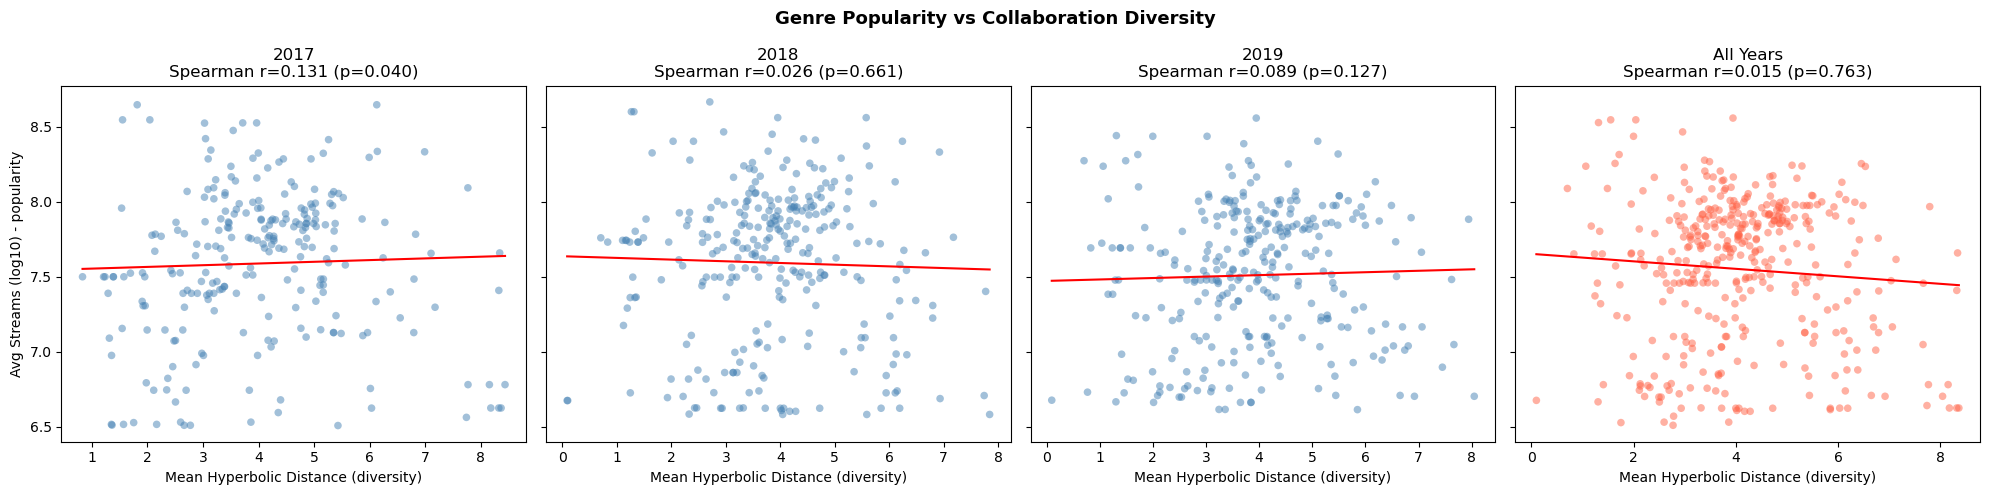

In [ ]:
# compute per-genre stats
source = all_years[["source", "avg_streams", "hyperbolic_distance", "year"]].rename(columns={"source": "genre"})
target = all_years[["target", "avg_streams", "hyperbolic_distance", "year"]].rename(columns={"target": "genre"})
combined = pd.concat([source, target], ignore_index=True)

genre_stats = combined.groupby(["genre", "year"]).agg(
    avg_streams=("avg_streams", "mean"),
    mean_diversity=("hyperbolic_distance", "mean")
).reset_index()

# all years combined per genre (ignore year)
genre_stats_all = combined.groupby("genre").agg(
    avg_streams=("avg_streams", "mean"),
    mean_diversity=("hyperbolic_distance", "mean")
).reset_index()

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle("Genre Popularity vs Collaboration Diversity", fontsize=13, fontweight="bold")

# individual years
for ax, year in zip(axes[:3], [2017, 2018, 2019]):
    year_df = genre_stats[genre_stats["year"] == year]
    ax.scatter(year_df["mean_diversity"],
               np.log10(year_df["avg_streams"]),
               alpha=0.5, color="steelblue", edgecolors="none", s=30)
    z = np.polyfit(year_df["mean_diversity"], np.log10(year_df["avg_streams"]), 1)
    x_line = np.linspace(year_df["mean_diversity"].min(), year_df["mean_diversity"].max(), 100)
    axes[list([2017, 2018, 2019]).index(year)].plot(x_line, np.poly1d(z)(x_line), color="red", linewidth=1.5)
    r, p = stats.spearmanr(year_df["mean_diversity"], year_df["avg_streams"])
    ax.set_title(f"{year}\nSpearman r={r:.3f} (p={p:.3f})")
    ax.set_xlabel("Mean Hyperbolic Distance (diversity)")
    if year == 2017:
        ax.set_ylabel("Avg Streams (log10) - popularity")

# all years
axes[3].scatter(genre_stats_all["mean_diversity"],
                np.log10(genre_stats_all["avg_streams"]),
                alpha=0.5, color="tomato", edgecolors="none", s=30)
z = np.polyfit(genre_stats_all["mean_diversity"], np.log10(genre_stats_all["avg_streams"]), 1)
x_line = np.linspace(genre_stats_all["mean_diversity"].min(), genre_stats_all["mean_diversity"].max(), 100)
axes[3].plot(x_line, np.poly1d(z)(x_line), color="red", linewidth=1.5)
r, p = stats.spearmanr(genre_stats_all["mean_diversity"], genre_stats_all["avg_streams"])
axes[3].set_title(f"All Years\nSpearman r={r:.3f} (p={p:.3f})")
axes[3].set_xlabel("Mean Hyperbolic Distance (diversity)")

plt.tight_layout()
plt.show()

In [ ]:
FAMILIES = {
    'Pop': {
        'genres': ['pop', 'dance pop', 'canadian pop', 'uk pop', 'art pop',
                   'post-teen pop', 'bedroom pop', 'indie pop', 'viral pop',
                   'new wave pop', 'singer-songwriter pop', 'pov: indie'],
        'color': '#e63946'
    },
    'Rap': {
        'genres': ['rap', 'pop rap', 'melodic rap', 'cloud rap', 'gangster rap',
                   'east coast hip hop', 'southern hip hop', 'atl hip hop',
                   'french hip hop', 'west coast rap', 'conscious hip hop',
                   'chicago rap'],
        'color': '#f4a261'
    },
    'Rock': {
        'genres': ['rock', 'modern rock', 'classic rock', 'alternative rock',
                   'hard rock', 'post-grunge', 'album rock', 'soft rock',
                   'indie rock', 'folk rock', 'pop rock', 'alternative metal'],
        'color': '#2a9d8f'
    },
    'Urbano Latino': {
        'genres': ['urbano latino', 'trap latino', 'reggaeton', 'musica mexicana',
                   'corrido', 'norteno', 'sierreno', 'banda', 'sad sierreno',
                   'reggaeton colombiano', 'latin pop', 'latin alternative'],
        'color': '#8338ec'
    },
    'Hip Hop': {
        'genres': ['hip hop', 'trap', 'atl hip hop', 'southern hip hop',
                   'urban contemporary', 'east coast hip hop', 'conscious hip hop',
                   'french hip hop', 'german hip hop', 'canadian hip hop',
                   'latin hip hop', 'old school hip hop'],
        'color': '#457b9d'
    },
}

all_collab_genres = set(df["source"].unique()) | set(df["target"].unique())

for family_name, family_info in FAMILIES.items():
    matched = [g for g in family_info["genres"] if g in all_collab_genres]
    missing = [g for g in family_info["genres"] if g not in all_collab_genres]
    extra = [g for g in all_collab_genres if g not in 
             [g for f in FAMILIES.values() for g in f["genres"]] 
             and g in family_info["genres"]]
    print(f"\n{family_name}:")
    print(f"  Matched: {len(matched)} — {matched}")
    print(f"  Missing from collab data: {missing}")

# genres in collab data not covered by any family
all_family_genres = {g for f in FAMILIES.values() for g in f["genres"]}
uncovered = all_collab_genres - all_family_genres
print(f"\nUncovered genres in collaboration data: {len(uncovered)}")
print(sorted(uncovered))

NameError: name 'df' is not defined